VANGUARD PROJECT - Customer Journey Reconstruction & Completion Time KPI

QUESTION : How will you reconstruct customer journeys from the web event logs?

In this notebook we will explore and reconstruct : SUCCESSFUL Journey --> The journey follows the expected sequence and reaches confirmation:  
START → STEP_1 → STEP_2 → STEP_3 → CONFIRM
Objective: Reconstruct each customer's journey through the process (start → step_1 → step_2 → step_3 → confirm), isolate only the journeys that "successfully complete the expected sequence", and measure "completion time" as a KPI to compare Test vs. Control groups.

Key definitions to establish in this notebook
- **Successful completion:** a journey that follows the exact expected step order and reaches `confirm`, with no skipped steps.
- **Unit of analysis:** completion is measured at the **journey (`visit_id`) level**, since a single client can have multiple visits, and not all visits represent an "attempt" at the same journey.
Completion time is calculated per journey, then optionally aggregated per client for reporting.
- **Journey start/end timestamps:** start = timestamp of the first `start` event in that visit; end = timestamp of the first `confirm` event in that visit (not the last, to avoid inflating time with repeated confirm clicks).
- **Long completion times:** identified via IQR, not deleted — flagged and reported both with and without them so the KPI isn't silently distorted either way.

DATASET: df_final_web_data Pt1 : https://raw.githubusercontent.com/data-bootcamp-v4/lessons/refs/heads/main/5_6_eda_inf_stats_tableau/project/files_for_project/df_final_web_data_pt_1.txt df_final_web_data Pt2 : https://raw.githubusercontent.com/data-bootcamp-v4/lessons/refs/heads/main/5_6_eda_inf_stats_tableau/project/files_for_project/df_final_web_data_pt_2.txt df_final_experiment_clients : https://raw.githubusercontent.com/data-bootcamp-v4/lessons/refs/heads/main/5_6_eda_inf_stats_tableau/project/files_for_project/df_final_experiment_clients.txt
df_demo : https://raw.githubusercontent.com/data-bootcamp-v4/lessons/refs/heads/main/5_6_eda_inf_stats_tableau/project/files_for_project/df_final_demo.txt

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [3]:
url_pt1 = "https://raw.githubusercontent.com/data-bootcamp-v4/lessons/refs/heads/main/5_6_eda_inf_stats_tableau/project/files_for_project/df_final_web_data_pt_1.txt"
url_pt2 = "https://raw.githubusercontent.com/data-bootcamp-v4/lessons/refs/heads/main/5_6_eda_inf_stats_tableau/project/files_for_project/df_final_web_data_pt_2.txt"
url_exp = "https://raw.githubusercontent.com/data-bootcamp-v4/lessons/refs/heads/main/5_6_eda_inf_stats_tableau/project/files_for_project/df_final_experiment_clients.txt"
url_demo = "https://raw.githubusercontent.com/data-bootcamp-v4/lessons/refs/heads/main/5_6_eda_inf_stats_tableau/project/files_for_project/df_final_demo.txt"
df1 = pd.read_csv(url_pt1)
df2 = pd.read_csv(url_pt2)
df_exp = pd.read_csv(url_exp)
df_demo = pd.read_csv(url_demo)

print(df1.shape, df2.shape, df_exp.shape, df_demo.shape)

(343141, 5) (412264, 5) (70609, 2) (70609, 9)


In [4]:
# Combine web data and convert time 


df_web = pd.concat([df1, df2], axis=0, ignore_index=True)
df_web['date_time'] = pd.to_datetime(df_web['date_time'], errors='coerce')

print(df_web.shape)
df_web.head()

(755405, 5)


,client_id,visitor_id,visit_id,process_step,date_time
0,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:27:07
1,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:26:51
2,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:19:22
3,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:19:13
4,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:18:04


In [5]:
# Check duplicates & missing values in df_web

print("--- df_web missing values ---")
print(df_web.isnull().sum())

print("\n--- df_web duplicates ---")
print(f"Fully duplicated rows: {df_web.duplicated().sum()}")

# Remove exact duplicate rows (safe to drop -- 100% identical across all 5 columns, not just repeated events)
df_web = df_web.drop_duplicates()
print(f"Shape after dropping exact duplicates: {df_web.shape}")

# Drop rows where date_time failed to convert (if any)
df_web = df_web[df_web['date_time'].notnull()]
print(f"Shape after dropping invalid dates: {df_web.shape}")

--- df_web missing values ---
client_id       0
visitor_id      0
visit_id        0
process_step    0
date_time       0
dtype: int64

--- df_web duplicates ---
Fully duplicated rows: 10764
Shape after dropping exact duplicates: (744641, 5)
Shape after dropping invalid dates: (744641, 5)


In [6]:
# Check df_exp BEFORE merging
# (if client_id is duplicated here, the merge will silently create duplicate rows in df_web)

print(f"df_exp shape: {df_exp.shape}")
print(f"Missing values:\n{df_exp.isnull().sum()}")
print(f"Duplicate client_id in df_exp: {df_exp['client_id'].duplicated().sum()}")

# If there ARE duplicate client_ids, keep only the first assignment
df_exp = df_exp.drop_duplicates(subset='client_id', keep='first')
print(f"df_exp shape after dedup: {df_exp.shape}")

df_exp shape: (70609, 2)
Missing values:
client_id        0
Variation    20109
dtype: int64
Duplicate client_id in df_exp: 0
df_exp shape after dedup: (70609, 2)


In [7]:
# Merge Variation into df_web, then filter

rows_before_merge = len(df_web)

df_web = pd.merge(df_web, df_exp, on='client_id', how='left')

# Sanity check: 

print(f"Rows before merge: {rows_before_merge}")
print(f"Rows after merge: {len(df_web)}")
assert rows_before_merge == len(df_web), "Merge changed row count -- check df_exp for duplicates!"

df_web_all = df_web.copy()                        # full reference version
df_web = df_web[df_web['Variation'].notnull()]     # filtered to experiment clients only

print(f"After filtering to experiment clients: {df_web.shape}")

Rows before merge: 744641
Rows after merge: 744641
After filtering to experiment clients: (317235, 6)


In [8]:
# Re-check duplicates AFTER the merge

print(f"Duplicated rows after merge: {df_web.duplicated().sum()}")
df_web = df_web.drop_duplicates()
print(f"Shape after final dedup: {df_web.shape}")

Duplicated rows after merge: 0
Shape after final dedup: (317235, 6)


In [9]:
# Check df_demo BEFORE merging (same principle as df_exp)

print(f"df_demo shape: {df_demo.shape}")
print(f"Missing values:\n{df_demo.isnull().sum()}")
print(f"Duplicate client_id in df_demo: {df_demo['client_id'].duplicated().sum()}")

# Drop rows with any missing value (small volume, ~14-15 rows -- safe to drop)
df_demo = df_demo.dropna()

# Drop duplicate client_id if any exist
df_demo = df_demo.drop_duplicates(subset='client_id', keep='first')
print(f"df_demo shape after cleaning: {df_demo.shape}")

df_demo shape: (70609, 9)
Missing values:
client_id            0
clnt_tenure_yr      14
clnt_tenure_mnth    14
clnt_age            15
gendr               14
num_accts           14
bal                 14
calls_6_mnth        14
logons_6_mnth       14
dtype: int64
Duplicate client_id in df_demo: 0
df_demo shape after cleaning: (70594, 9)


In [10]:
# Merge demo data in, same row-count safety check

rows_before_demo_merge = len(df_web)

df_web = pd.merge(df_web, df_demo, on='client_id', how='left')

print(f"Rows before demo merge: {rows_before_demo_merge}")
print(f"Rows after demo merge: {len(df_web)}")
assert rows_before_demo_merge == len(df_web), "Merge changed row count -- check df_demo for duplicates!"

print(f"Missing demo info after merge: {df_web[['clnt_age','bal']].isnull().sum()}")

Rows before demo merge: 317235
Rows after demo merge: 317235
Missing demo info after merge: clnt_age    112
bal         112
dtype: int64


Explore - Print journeys containing all events exactly as they happened

In [11]:
df_web = df_web.sort_values(
    by=['visit_id', 'date_time']
).reset_index(drop=True)

In [11]:
journey_check = (
    df_web.groupby('visit_id')['process_step']
    .apply(list)
    .reset_index(name='journey')
)

journey_check.head(10)

,visit_id,journey
0,100012776_37918976071_457913,"[confirm, confirm]"
1,100019538_17884295066_43909,"[start, step_1, step_2, step_1, step_1, start,..."
2,100022086_87870757897_149620,"[start, step_1, step_2, step_3, confirm]"
3,100030127_47967100085_936361,[start]
4,100037962_47432393712_705583,"[start, start, step_1, start]"
5,100057941_88477660212_944512,"[start, step_1, step_2, step_3, step_1, step_2..."
6,10006594_66157970412_679648,"[start, step_1, step_2, step_3, step_3, confir..."
7,100071743_53464757454_616703,[start]
8,10007589_47780784567_391490,"[start, step_1, step_2, step_3, confirm]"
9,100096068_8301717872_987164,"[start, step_1]"


journeys that are not a straight path

In [12]:
ideal_path = ['start', 'step_1', 'step_2', 'step_3', 'confirm']

journey_check['is_ideal'] = (
    journey_check['journey']
    .apply(lambda x: x == ideal_path)
)

journey_check['is_ideal'].value_counts()

is_ideal
False    49381
True     19824
Name: count, dtype: int64

customers with detours

In [13]:
non_ideal = journey_check[
    ~journey_check['is_ideal']
]

non_ideal.head(20)

,visit_id,journey,is_ideal
0,100012776_37918976071_457913,"[confirm, confirm]",False
1,100019538_17884295066_43909,"[start, step_1, step_2, step_1, step_1, start,...",False
3,100030127_47967100085_936361,[start],False
4,100037962_47432393712_705583,"[start, start, step_1, start]",False
5,100057941_88477660212_944512,"[start, step_1, step_2, step_3, step_1, step_2...",False
6,10006594_66157970412_679648,"[start, step_1, step_2, step_3, step_3, confir...",False
7,100071743_53464757454_616703,[start],False
9,100096068_8301717872_987164,"[start, step_1]",False
10,100105975_18174738494_196339,"[start, start]",False
12,100195539_90558871716_822894,"[start, step_1, start, step_1]",False


successful journeys with extra actions

In [14]:
successful_nonlinear = journey_check[
    journey_check['journey'].apply(lambda x:
    ('confirm' in x) &
    (x != ideal_path)
)
]

successful_nonlinear.head(20)

,visit_id,journey,is_ideal
0,100012776_37918976071_457913,"[confirm, confirm]",False
1,100019538_17884295066_43909,"[start, step_1, step_2, step_1, step_1, start,...",False
6,10006594_66157970412_679648,"[start, step_1, step_2, step_3, step_3, confir...",False
13,100217156_67053490690_383412,"[start, step_1, step_1, step_2, step_3, step_1...",False
18,100258507_71262593004_214494,"[start, start, start, step_1, start, start, st...",False
28,100471971_3065983298_584030,"[start, start, step_1, step_2, step_3, confirm]",False
29,100475449_39139591577_836652,[confirm],False
30,100481857_71511233596_788753,"[start, step_1, step_2, step_3, step_2, step_3...",False
34,10056419_61656665964_803695,"[start, step_1, start, step_1, step_2, step_3,...",False
37,100618014_41463020246_787063,"[confirm, start, step_1]",False


backward navigation

In [19]:
df_web['process_step'].unique()

<StringArray>
['confirm', 'start', 'step_1', 'step_2', 'step_3']
Length: 5, dtype: str

In [20]:
step_order_map = {
    'start': 0,
    'step_1': 1,
    'step_2': 2,
    'step_3': 3,
    'confirm': 4
}

In [21]:
journey_check['has_backtracking'] = journey_check['journey'].apply(
    lambda x: any(
    step_order_map[x[i]] > step_order_map[x[i+1]]
    for i in range(len(x)-1)
    )
)

journey_check['has_backtracking'].value_counts()

has_backtracking
False    52586
True     16619
Name: count, dtype: int64

Few real journey with timestamps

In [22]:
sample_visit = df_web['visit_id'].sample(1).iloc[0]

df_web.loc[
    df_web['visit_id'] == sample_visit,
        ['visit_id', 'date_time', 'process_step']
].sort_values('date_time')

,visit_id,date_time,process_step
26718,175287340_40919850763_431475,2017-05-28 16:16:57,start
26719,175287340_40919850763_431475,2017-05-28 16:17:42,step_1
26720,175287340_40919850763_431475,2017-05-28 16:18:02,step_2


creating a numeric order for process_step to check whether a journey moves through the steps in the correct sequence, not just whether all 5 steps happen to be present.

In [23]:
# Map process_step to a numeric order

step_order_map = {
    'start': 0,
    'step_1': 1,
    'step_2': 2,
    'step_3': 3,
    'confirm': 4
}
df_web['step_order'] = df_web['process_step'].map(step_order_map)

# Sort so every visit's events are in chronological order
df_web = df_web.sort_values(by=['visit_id', 'date_time']).reset_index(drop=True)

For each visit_id, we collect:
the full sequence of steps visited, in time order (with consecutive duplicates collapsed — e.g. start, start, step_1 becomes start, step_1)
the first start timestamp
the first confirm timestamp (if any)
the client and Variation for that visit

In [24]:
# Build one row per visit_id (journey-level table)

def build_journey(group):
    # Collapse consecutive duplicate steps (e.g. step_2, step_2 -> step_2)
    steps_in_order = group['process_step'].tolist()
    collapsed = [steps_in_order[0]]
    for s in steps_in_order[1:]:
        if s != collapsed[-1]:
            collapsed.append(s)

    return pd.Series({
        'client_id': group['client_id'].iloc[0],
        'Variation': group['Variation'].iloc[0],
        'step_sequence': collapsed,
        'start_time': group.loc[group['process_step'] == 'start', 'date_time'].min(),
        'confirm_time': group.loc[group['process_step'] == 'confirm', 'date_time'].min(),
        'n_events': len(group)
    })

journeys = df_web.groupby('visit_id').apply(build_journey, include_groups=False).reset_index()

print(journeys.shape)
journeys.head()

(69205, 7)


,visit_id,client_id,Variation,step_sequence,start_time,confirm_time,n_events
0,100012776_37918976071_457913,3561384,Test,[confirm],NaT,2017-04-26 13:22:17,2
1,100019538_17884295066_43909,7338123,Test,"[start, step_1, step_2, step_1, start, step_1,...",2017-04-09 16:20:56,2017-04-09 16:24:58,11
2,100022086_87870757897_149620,2478628,Test,"[start, step_1, step_2, step_3, confirm]",2017-05-23 20:44:01,2017-05-23 20:47:01,5
3,100030127_47967100085_936361,105007,Control,[start],2017-03-22 11:07:49,NaT,1
4,100037962_47432393712_705583,5623007,Control,"[start, step_1, start]",2017-04-14 16:41:51,NaT,4


Without collapsing repeated steps 

In [25]:
# Build one row per visit_id without collapsing repeated steps

def build_journey_raw(group):

    return pd.Series({
        'client_id': group['client_id'].iloc[0],
        'Variation': group['Variation'].iloc[0],
        'step_sequence': group['process_step'].tolist(), # keep all steps
        'start_time': group.loc[group['process_step']=='start', 'date_time'].min(),
        'confirm_time': group.loc[group['process_step']=='confirm', 'date_time'].min(),
        'n_events': len(group)
})

journeys_raw = (
    df_web
    .sort_values(['visit_id', 'date_time'])
    .groupby('visit_id')
    .apply(build_journey_raw, include_groups=False)
    .reset_index()
)

journeys_raw.head()

,visit_id,client_id,Variation,step_sequence,start_time,confirm_time,n_events
0,100012776_37918976071_457913,3561384,Test,"[confirm, confirm]",NaT,2017-04-26 13:22:17,2
1,100019538_17884295066_43909,7338123,Test,"[start, step_1, step_2, step_1, step_1, start,...",2017-04-09 16:20:56,2017-04-09 16:24:58,11
2,100022086_87870757897_149620,2478628,Test,"[start, step_1, step_2, step_3, confirm]",2017-05-23 20:44:01,2017-05-23 20:47:01,5
3,100030127_47967100085_936361,105007,Control,[start],2017-03-22 11:07:49,NaT,1
4,100037962_47432393712_705583,5623007,Control,"[start, start, step_1, start]",2017-04-14 16:41:51,NaT,4


Compare both table with duplicates vs without 

In [26]:
comparison = (
    journeys[['visit_id', 'n_events']]
    .merge(
        journeys_raw[['visit_id', 'n_events']],
        on='visit_id',
        suffixes=('_collapsed', '_raw')
    )
)

comparison['duplicates_removed'] = (
    comparison['n_events_raw']
    - comparison['n_events_collapsed']
)

comparison['duplicates_removed'].describe()

count    69205.0
mean         0.0
std          0.0
min          0.0
25%          0.0
50%          0.0
75%          0.0
max          0.0
Name: duplicates_removed, dtype: float64

Compare Test vs Control 

In [27]:
comparison = comparison.merge(
    journeys[['visit_id', 'Variation']],
    on='visit_id'
)

comparison.groupby('Variation')['duplicates_removed'].agg([
    'count',
    'mean',
    'median',
    'max'
])

,count,mean,median,max
Variation,,,,
Control,32120,0.0,0.0,0
Test,37085,0.0,0.0,0


When comparing with and without duplicates it has no effect on the data.
The duplicate check produced identical results in both experimental groups.
Neither the Control group nor the Test group contained duplicate observations according to your duplicate definition.

In [28]:
# Journey Length

journeys_raw.groupby('Variation')['n_events'].describe()

,count,mean,std,min,25%,50%,75%,max
Variation,,,,,,,,
Control,32120.0,4.371793,2.714780,1.0,2.0,5.0,5.0,35.0
Test,37085.0,4.767777,2.931783,1.0,2.0,5.0,6.0,61.0


Compare most common path with duplicates - Most frequest navigation patterns

In [29]:
journeys_raw['path'] = journeys_raw['step_sequence'].apply(
    lambda x: " > ".join(x)
)

journeys_raw.groupby('Variation')['path']\
    .value_counts()\
    .groupby(level=0)\
    .head(10)

Variation  path                                                        
Control    start > step_1 > step_2 > step_3 > confirm                       9349
           start                                                            5031
           start > step_1                                                   2289
           start > start                                                    1722
           start > step_1 > step_2 > step_3                                 1309
           start > step_1 > step_2                                          1061
           start > start > step_1 > step_2 > step_3 > confirm                652
           confirm                                                           587
           start > step_1 > step_2 > step_3 > step_2 > step_3 > confirm      564
           start > start > start                                             320
Test       start > step_1 > step_2 > step_3 > confirm                      10475
           start                     

Two journey-level datasets were created. The first collapsed consecutive duplicate steps to identify the intended navigation flow, while the second preserved all events to capture actual user behavior. Comparing both versions allows the identification of repeated actions, potential confusion points, and differences in navigation efficiency between the Control and Test groups.

I decided for the Vanguard project, to remove the duplicates because repeated steps can be treated as friction in the user experience.

A journey is successful only if its collapsed step sequence is exactly ['start', 'step_1', 'step_2', 'step_3', 'confirm'] — no skipped steps, no out-of-order steps.

In [30]:
# Flag successful journeys (exact expected sequence)

expected_sequence = ['start', 'step_1', 'step_2', 'step_3', 'confirm']

journeys['is_successful'] = journeys['step_sequence'].apply(lambda seq: seq == expected_sequence)

success_counts = journeys['is_successful'].value_counts()
print(success_counts)
print(f"Success rate: {journeys['is_successful'].mean() * 100:.2f}%")

is_successful
False    44317
True     24888
Name: count, dtype: int64
Success rate: 35.96%


Results: only about **36%** of clients completed the **full process**, while 64% dropped off at some point before confirmation.
-**Successful journeys** = 24,858
-**Unsuccessful journeys** = 44,347
-**Success rate** = 35.92%

In [31]:
# Preview a few successful and unsuccessful journeys side by side

print("Example successful journey:")
print(journeys[journeys['is_successful']].iloc[0][['visit_id', 'step_sequence']])

print("\nExample unsuccessful journey:")
print(journeys[~journeys['is_successful']].iloc[0][['visit_id', 'step_sequence']])

Example successful journey:
visit_id                     100022086_87870757897_149620
step_sequence    [start, step_1, step_2, step_3, confirm]
Name: 2, dtype: object

Example unsuccessful journey:
visit_id         100012776_37918976071_457913
step_sequence                       [confirm]
Name: 0, dtype: object


Filter to only successful journeys

From here on, I worked with a **filtered view** (journeys_success)

In [32]:
# Filter to successful journeys only

journeys_success = journeys[journeys['is_successful']].copy()

print(f"All journeys: {len(journeys)}")
print(f"Successful journeys: {len(journeys_success)}")
print(journeys_success['Variation'].value_counts())

All journeys: 69205
Successful journeys: 24888
Variation
Test       13579
Control    11309
Name: count, dtype: int64


Visual distribution 

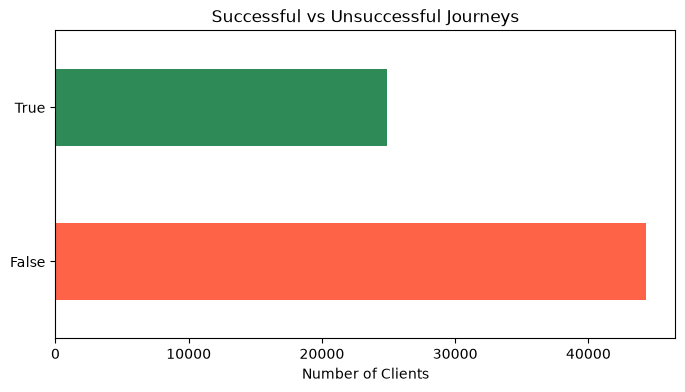

In [33]:
success_counts.plot(
    kind='barh',
    color=['grey', 'blue'],
    figsize=(8,4)
)

plt.title('Successful vs Unsuccessful Journeys')
plt.xlabel('Number of Clients')
plt.ylabel('')

plt.show()

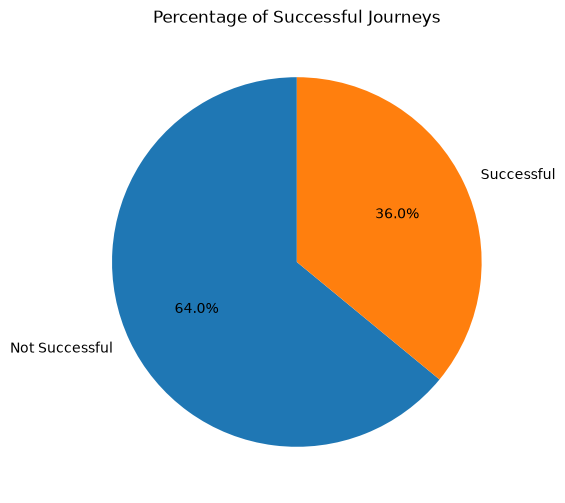

In [34]:
plt.figure(figsize=(6,6))

plt.pie(
    success_counts,
    labels=['Not Successful', 'Successful'],
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Percentage of Successful Journeys')
plt.show()

Success vs unsuccess 

In [1]:
journey_summary = journeys.groupby(['Variation', 'is_successful']) \
                            .size() \
                            .unstack(fill_value=0)

journey_summary.plot(
    kind='bar',
    stacked=True,
    figsize=(8,5),
    color=['grey', 'steelblue']
)

plt.title('Journey Outcomes by Variation')
plt.xlabel('Variation')
plt.ylabel('Number of Journeys')
plt.legend(['Unsuccessful', 'Successful'])

plt.xticks(rotation=0)

plt.show()

NameError: name 'journeys' is not defined

/var/folders/t1/g1ptmxln4nx5k_rz9978lf340000gn/T/ipykernel_11789/368755030.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


<Axes: xlabel='Variation', ylabel='is_successful'>

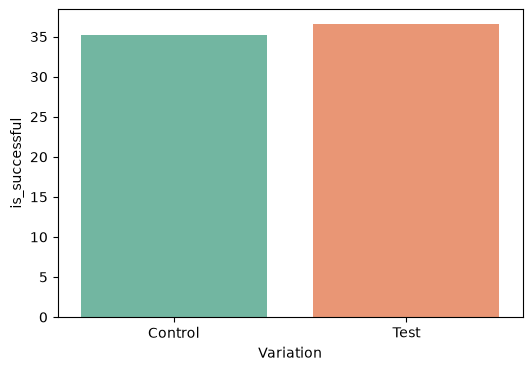

In [36]:
# Success rate Comparison 

success_rate = (
    journeys.groupby('Variation')['is_successful']
    .mean()
    .mul(100)
    .reset_index()
)

plt.figure(figsize=(6,4))

sns.barplot(
    data=success_rate,
    x='Variation',
    y='is_successful',
    palette='Set2'
)

Compare Success Rate by Test vs Control

In [37]:
pd.crosstab(
    journeys['Variation'],
    journeys['is_successful'],
    normalize='index'
) * 100

is_successful,False,True
Variation,,
Control,64.791407,35.208593
Test,63.384118,36.615882


In [38]:
success_by_group = pd.crosstab(
    journeys['Variation'],
    journeys['is_successful'],
    normalize='index'
) * 100

A total of 24,858 clients completed the full sequence (start → step_1 → step_2 → step_3 → confirm), representing a success rate of 35.9%. Conversely, 64.1% of clients did not complete all required steps, indicating substantial drop-off throughout the journey.

a sample journey table with few successful journeys 

In [39]:
sample_visits = (
    journeys_success['visit_id']
    .sample(10, random_state=42)
)

sample_journeys = df_web[
    df_web['visit_id'].isin(sample_visits)
    ].sort_values(['visit_id', 'date_time'])

sample_journeys[
    ['visit_id',
    'client_id',
    'Variation',
    'date_time',
    'process_step']
]

,visit_id,client_id,Variation,date_time,process_step
31449,188569888_74231573959_12015,9752107,Control,2017-04-11 19:29:29,start
31450,188569888_74231573959_12015,9752107,Control,2017-04-11 19:30:07,step_1
31451,188569888_74231573959_12015,9752107,Control,2017-04-11 19:30:54,step_2
31452,188569888_74231573959_12015,9752107,Control,2017-04-11 19:31:55,step_3
31453,188569888_74231573959_12015,9752107,Control,2017-04-11 19:34:09,confirm
77675,320554356_11982551977_289639,9482404,Test,2017-05-27 13:55:14,start
77676,320554356_11982551977_289639,9482404,Test,2017-05-27 13:55:24,step_1
77677,320554356_11982551977_289639,9482404,Test,2017-05-27 13:56:59,step_2
77678,320554356_11982551977_289639,9482404,Test,2017-05-27 14:01:50,step_3
77679,320554356_11982551977_289639,9482404,Test,2017-05-27 14:07:49,confirm


Calculate time between steps

In [40]:
sample_journeys['time_to_next_step'] = (
    sample_journeys.groupby('visit_id')['date_time']
    .diff()
    .dt.total_seconds()
)

sample_journeys

,client_id,visitor_id,visit_id,process_step,date_time,Variation,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth,step_order,time_to_next_step
31449,9752107,168291259_75756801116,188569888_74231573959_12015,start,2017-04-11 19:29:29,Control,13.0,166.0,44.5,M,2.0,55655.10,0.0,3.0,0,NaN
31450,9752107,168291259_75756801116,188569888_74231573959_12015,step_1,2017-04-11 19:30:07,Control,13.0,166.0,44.5,M,2.0,55655.10,0.0,3.0,1,38.0
31451,9752107,168291259_75756801116,188569888_74231573959_12015,step_2,2017-04-11 19:30:54,Control,13.0,166.0,44.5,M,2.0,55655.10,0.0,3.0,2,47.0
31452,9752107,168291259_75756801116,188569888_74231573959_12015,step_3,2017-04-11 19:31:55,Control,13.0,166.0,44.5,M,2.0,55655.10,0.0,3.0,3,61.0
31453,9752107,168291259_75756801116,188569888_74231573959_12015,confirm,2017-04-11 19:34:09,Control,13.0,166.0,44.5,M,2.0,55655.10,0.0,3.0,4,134.0
77675,9482404,825224283_64608426876,320554356_11982551977_289639,start,2017-05-27 13:55:14,Test,28.0,337.0,64.0,F,2.0,107315.26,2.0,5.0,0,NaN
77676,9482404,825224283_64608426876,320554356_11982551977_289639,step_1,2017-05-27 13:55:24,Test,28.0,337.0,64.0,F,2.0,107315.26,2.0,5.0,1,10.0
77677,9482404,825224283_64608426876,320554356_11982551977_289639,step_2,2017-05-27 13:56:59,Test,28.0,337.0,64.0,F,2.0,107315.26,2.0,5.0,2,95.0
77678,9482404,825224283_64608426876,320554356_11982551977_289639,step_3,2017-05-27 14:01:50,Test,28.0,337.0,64.0,F,2.0,107315.26,2.0,5.0,3,291.0
77679,9482404,825224283_64608426876,320554356_11982551977_289639,confirm,2017-05-27 14:07:49,Test,28.0,337.0,64.0,F,2.0,107315.26,2.0,5.0,4,359.0


In [41]:
for visit in sample_visits[:5]:

    temp = (
    df_web[df_web['visit_id'] == visit]
    .sort_values('date_time')
)

    print(f"\nVisit ID: {visit}")
    print("-"*50)

    for _, row in temp.iterrows():
        print(
            f"{row['date_time']} -> {row['process_step']}"
)


Visit ID: 496783568_22646155951_610801
--------------------------------------------------
2017-05-16 10:22:48 -> start
2017-05-16 10:22:57 -> step_1
2017-05-16 10:23:15 -> step_2
2017-05-16 10:23:55 -> step_3
2017-05-16 10:25:44 -> confirm

Visit ID: 875431944_81257472631_59580
--------------------------------------------------
2017-03-30 12:42:24 -> start
2017-03-30 12:42:54 -> step_1
2017-03-30 12:45:45 -> step_2
2017-03-30 12:46:57 -> step_3
2017-03-30 12:51:38 -> confirm

Visit ID: 902764042_2278690799_597490
--------------------------------------------------
2017-04-22 16:47:11 -> start
2017-04-22 16:47:17 -> step_1
2017-04-22 16:47:35 -> step_2
2017-04-22 16:49:47 -> step_3
2017-04-22 16:50:11 -> confirm
2017-04-22 16:51:08 -> confirm

Visit ID: 740323830_68640167698_1486
--------------------------------------------------
2017-04-19 11:10:46 -> start
2017-04-19 11:10:49 -> step_1
2017-04-19 11:11:13 -> step_2
2017-04-19 11:12:15 -> step_3
2017-04-19 11:13:41 -> confirm

Visit ID

Compare Fast vs Slow Journeys

In [42]:
journeys_success['completion_time_sec'] = (
    journeys_success['confirm_time']
    - journeys_success['start_time']
).dt.total_seconds()

In [43]:
fastest = journeys_success.nsmallest(
    5,
    'completion_time_sec'
)

slowest = journeys_success.nlargest(
    5,
    'completion_time_sec'
)

print("FASTEST JOURNEYS")
display(
    fastest[['visit_id', 'Variation', 'completion_time_sec']]
)

print("SLOWEST JOURNEYS")
display(
    slowest[['visit_id', 'Variation', 'completion_time_sec']]
)

FASTEST JOURNEYS


,visit_id,Variation,completion_time_sec
32355,521746641_11461043062_20924,Control,35.0
30685,500287246_1823996223_688506,Control,38.0
50637,757553116_12607145468_480013,Test,38.0
61823,903644159_86550905805_777426,Test,38.0
25857,438084877_41971989524_550398,Control,39.0


SLOWEST JOURNEYS


,visit_id,Variation,completion_time_sec
40487,627596734_90499955288_891366,Control,11351.0
1678,121539902_39215756141_237356,Test,8005.0
60813,89076580_51739503136_236731,Control,6849.0
61629,901045687_93987650598_395894,Test,5280.0
34902,554897609_58242917017_669621,Test,4988.0


**Ideal Journey**
start → step_1 → step_2 → step_3 → confirm

**Fast Journey**
start → step_1 → step_2 → step_3 → confirm
Duration: 35 sec

**Slow Journey**
start → step_1 → step_2 → step_1 → step_2 → step_3 → confirm
Duration: 3h 9min 11second

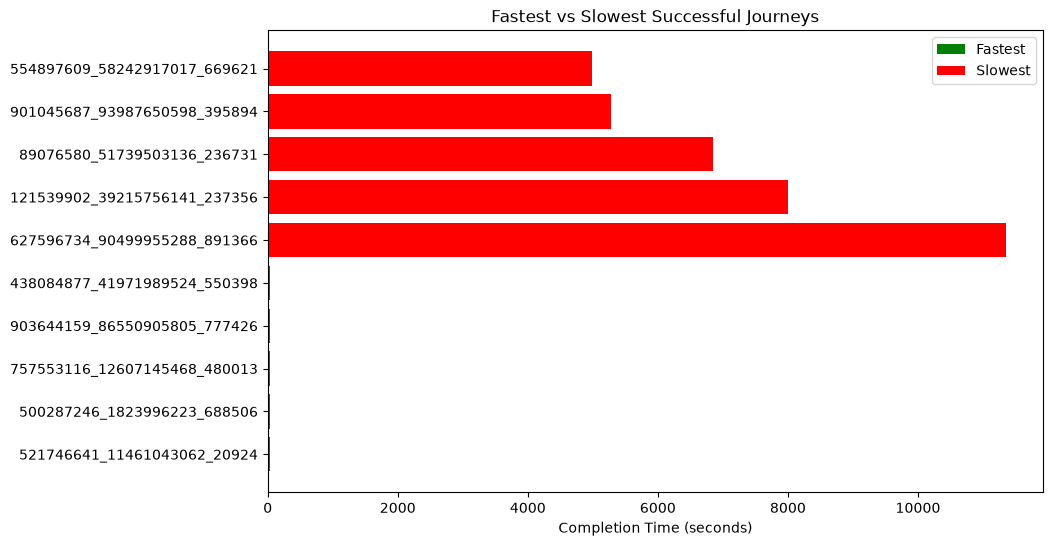

In [44]:
top5_fast = journeys_success.nsmallest(
    5,
    'completion_time_sec'
)

top5_slow = journeys_success.nlargest(
    5,
    'completion_time_sec'
)

plt.figure(figsize=(10,6))

plt.barh(
    top5_fast['visit_id'].astype(str),
    top5_fast['completion_time_sec'],
    color='green',
    label='Fastest'
)

plt.barh(
    top5_slow['visit_id'].astype(str),
    top5_slow['completion_time_sec'],
    color='red',
    label='Slowest'
)

plt.xlabel('Completion Time (seconds)')
plt.title('Fastest vs Slowest Successful Journeys')
plt.legend()
plt.show()

In [45]:
fast_visit = fastest.iloc[0]['visit_id']
slow_visit = slowest.iloc[0]['visit_id']

fast_journey = (
    df_web[df_web['visit_id'] == fast_visit]
    .sort_values('date_time')
)

slow_journey = (
    df_web[df_web['visit_id'] == slow_visit]
    .sort_values('date_time')
)

In [46]:
fast_journey = fast_journey.copy()
slow_journey = slow_journey.copy()

fast_journey['elapsed_sec'] = (
    fast_journey['date_time']
    - fast_journey['date_time'].min()
).dt.total_seconds()

slow_journey['elapsed_sec'] = (
    slow_journey['date_time']
    - slow_journey['date_time'].min()

).dt.total_seconds()

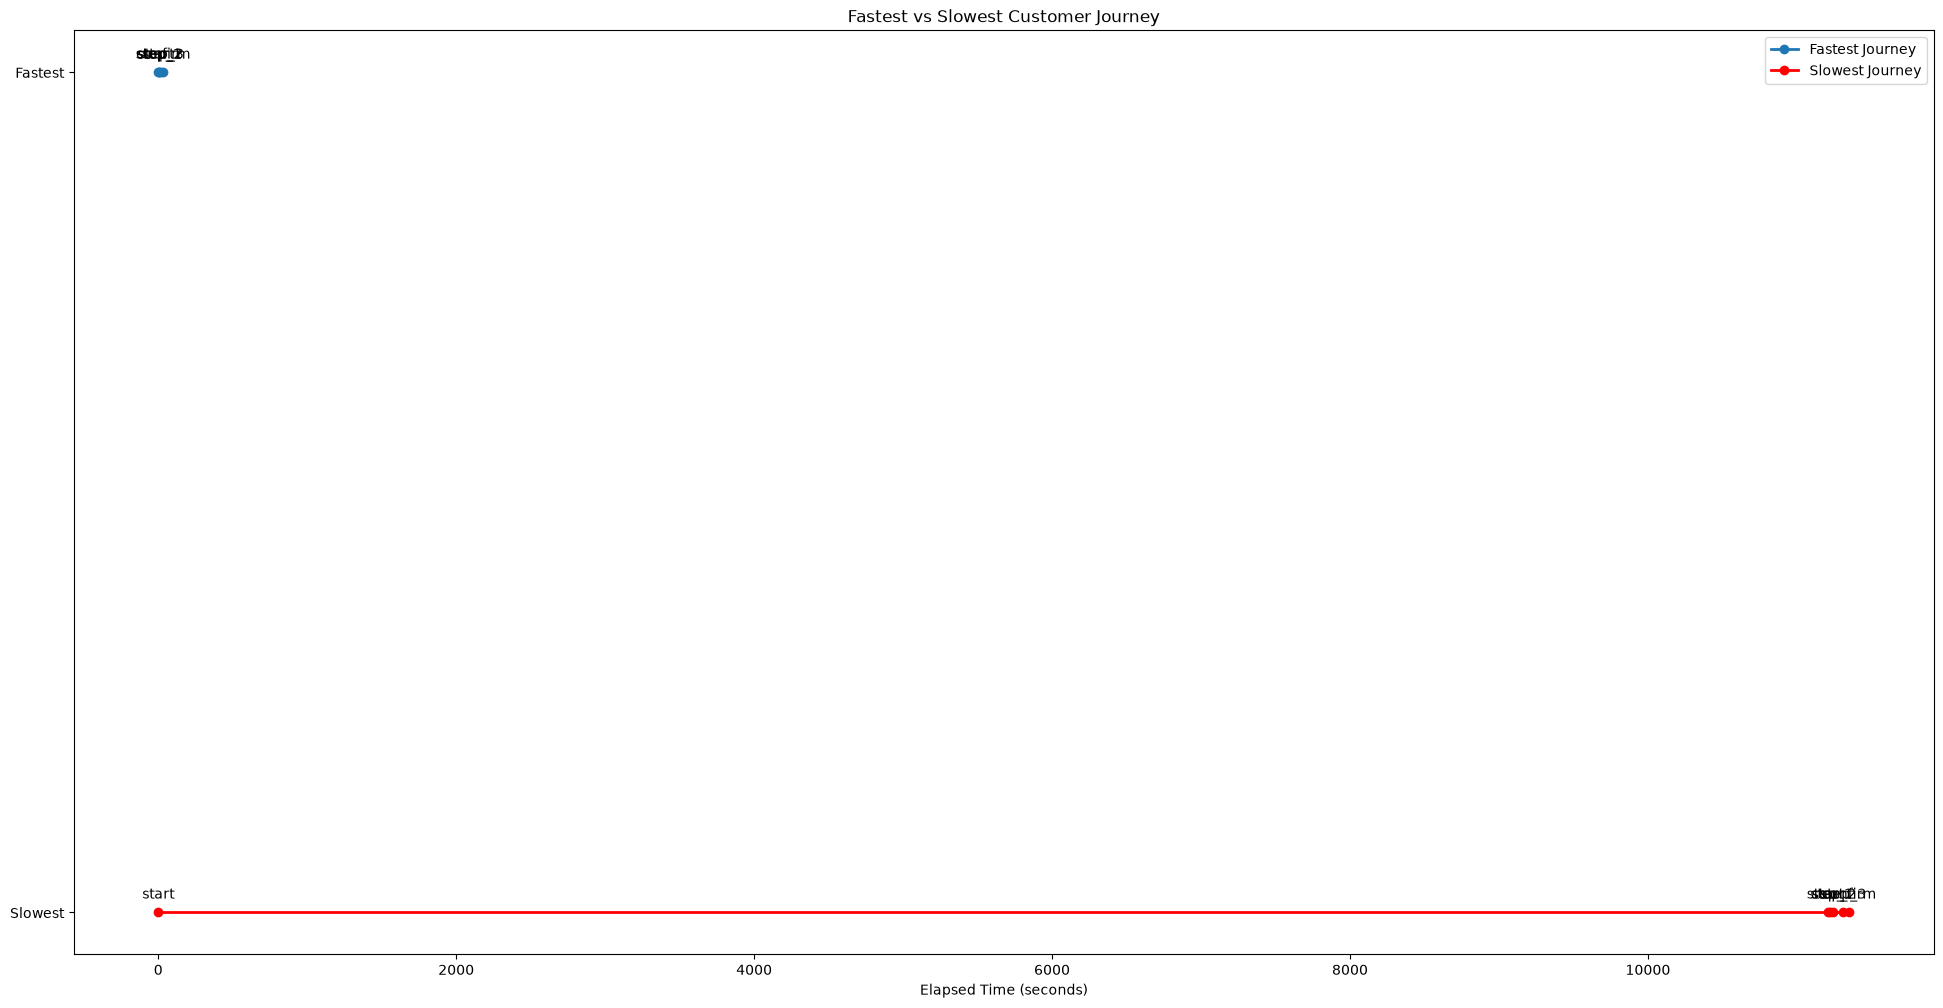

In [47]:
fig, ax = plt.subplots(figsize=(24,12))

# Fast journey
ax.plot(
    fast_journey['elapsed_sec'],
    [1]*len(fast_journey),
    marker='o',
    linewidth=2,
    label='Fastest Journey'
)

for _, row in fast_journey.iterrows():
    ax.annotate(
        row['process_step'],
        (row['elapsed_sec'],1),
        xytext=(0,10),
        textcoords='offset points',
        ha='center'

    )

# Slow journey
ax.plot(
    slow_journey['elapsed_sec'],
    [0]*len(slow_journey),
    marker='o',
    linewidth=2,
    color='red',
    label='Slowest Journey'
)

for _, row in slow_journey.iterrows():
    ax.annotate(
        row['process_step'],
        (row['elapsed_sec'],0),
        xytext=(0,10),
        textcoords='offset points',
        ha='center'
)

ax.set_yticks([0,1])
ax.set_yticklabels(['Slowest','Fastest'])

ax.set_xlabel('Elapsed Time (seconds)')
ax.set_title('Fastest vs Slowest Customer Journey')

plt.legend()
plt.show()

Compute completion time per journey

Start timestamp = first start event in the visit. End timestamp = first confirm event in the visit (using the first, not the last, avoids inflating completion time for visits with multiple confirm clicks — already filtered to successful/clean sequences here, but kept as a defensive default).

Completion time is calculated per journey (visit_id) here, since that's the natural unit an "attempt" happens in. We'll also aggregate to the client level afterward for anyone who wants a per-client summary.

In [48]:
# Calculate completion time (in minutes) per journey

journeys_success['completion_time_min'] = (
    journeys_success['confirm_time'] - journeys_success['start_time']
).dt.total_seconds() / 60

journeys_success['completion_time_min'].describe()

count    24888.000000
mean         5.151234
std          5.171063
min          0.583333
25%          2.400000
50%          3.650000
75%          5.950000
max        189.183333
Name: completion_time_min, dtype: float64

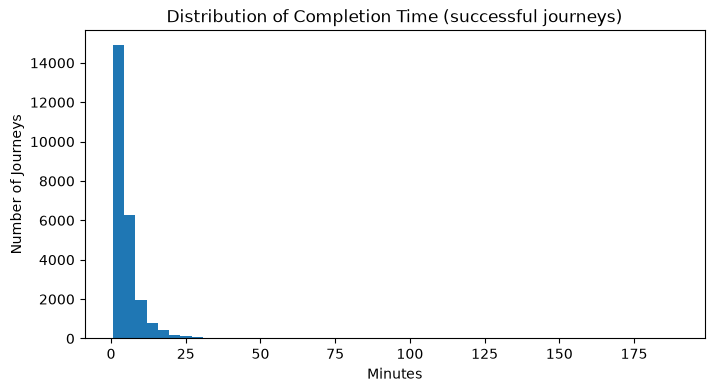

In [49]:
# Visualize the distribution
plt.figure(figsize=(8, 4))
plt.hist(journeys_success['completion_time_min'], bins=50)
plt.title('Distribution of Completion Time (successful journeys)')
plt.xlabel('Minutes')
plt.ylabel('Number of Journeys')
plt.show()

Handle exceptionally long completion times

Rather than deleting outliers, we flag them using the IQR method, and report the completion-time KPI both with and without them included. This keeps the analysis transparent about how much outliers are influencing the headline number, without silently discarding data.

In [50]:
# Flag (not remove) unusually long completion times

Q1 = journeys_success['completion_time_min'].quantile(0.25)
Q3 = journeys_success['completion_time_min'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

journeys_success['is_long_completion'] = journeys_success['completion_time_min'] > upper_bound

print(f"Upper bound for 'normal' completion time: {upper_bound:.2f} minutes")
print(f"Flagged as unusually long: {journeys_success['is_long_completion'].sum()}")
print(f"Percentage flagged: {journeys_success['is_long_completion'].mean() * 100:.2f}%")

Upper bound for 'normal' completion time: 11.28 minutes
Flagged as unusually long: 1941
Percentage flagged: 7.80%


/var/folders/t1/g1ptmxln4nx5k_rz9978lf340000gn/T/ipykernel_11789/726743979.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


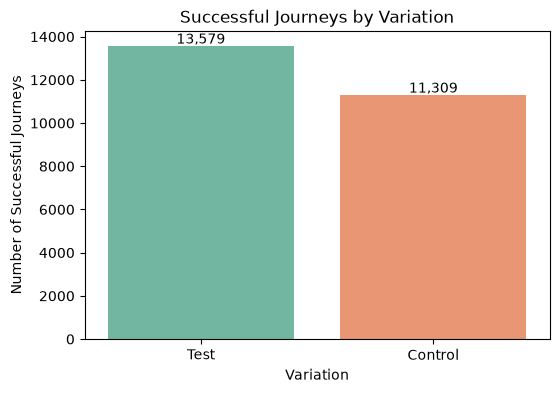

In [51]:
# visualisation

success_counts = journeys_success['Variation'].value_counts()

plt.figure(figsize=(6,4))

sns.barplot(
    x=success_counts.index,
    y=success_counts.values,
    palette='Set2',
)
plt.title('Successful Journeys by Variation'),
plt.xlabel('Variation'),
plt.ylabel('Number of Successful Journeys'),



for i, value in enumerate(success_counts.values):
    plt.text(i, value + 100, f'{value:,}', ha='center')

plt.show()

In [52]:
# Compare the KPI with vs. without the flagged long journeys
with_outliers = journeys_success['completion_time_min'].mean()
without_outliers = journeys_success.loc[~journeys_success['is_long_completion'], 'completion_time_min'].mean()

print(f"Mean completion time (all successful journeys): {with_outliers:.2f} min")
print(f"Mean completion time (excluding flagged long ones): {without_outliers:.2f} min")
print(f"Median completion time (robust to outliers): {journeys_success['completion_time_min'].median():.2f} min")

Mean completion time (all successful journeys): 5.15 min
Mean completion time (excluding flagged long ones): 4.04 min
Median completion time (robust to outliers): 3.65 min


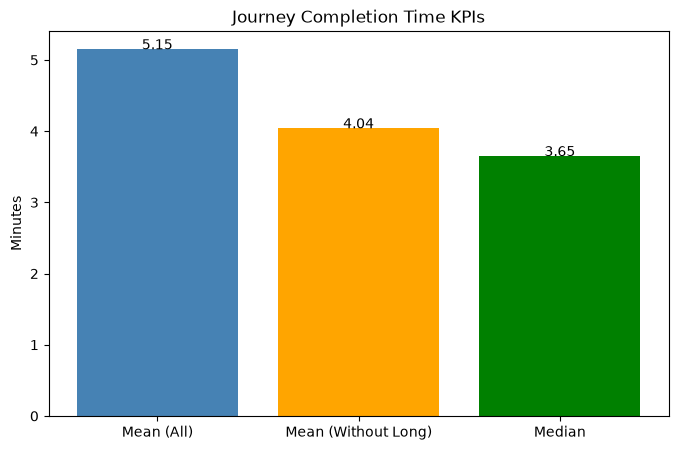

In [53]:
kpis = ['Mean (All)', 'Mean (Without Long)', 'Median']
values = [5.15, 4.04, 3.65]

plt.figure(figsize=(8,5))
bars = plt.bar(kpis, values, color=['steelblue','orange','green'])

plt.ylabel('Minutes')
plt.title('Journey Completion Time KPIs')

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f'{bar.get_height():.2f}',
        ha='center'
)

plt.show()

The median completion time is 3.65 minutes, while the overall average rises to 5.15 minutes due to a small number of unusually long journeys.

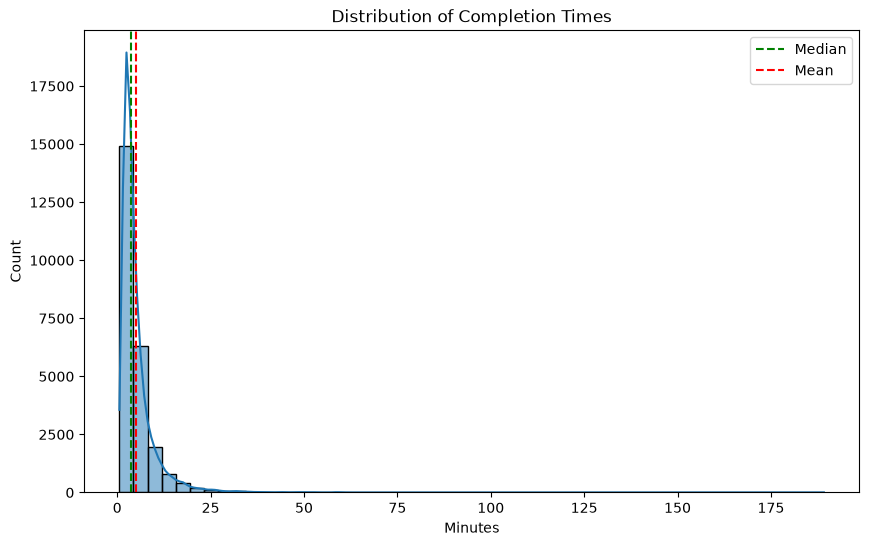

In [54]:
plt.figure(figsize=(10,6))

sns.histplot(
    journeys_success['completion_time_min'],
    bins=50,
    kde=True
)

plt.axvline(
    journeys_success['completion_time_min'].median(),
    color='green',
    linestyle='--',
    label='Median'
)

plt.axvline(
    journeys_success['completion_time_min'].mean(),
    color='red',
    linestyle='--',
    label='Mean'
)

plt.legend()
plt.title('Distribution of Completion Times')
plt.xlabel('Minutes')

plt.show()

Completion time KPI: Test vs. Control

In [55]:
# Compare completion time by Variation

completion_by_group = journeys_success.groupby('Variation')['completion_time_min'].agg(
    ['count', 'mean', 'median', 'std']
)
print(completion_by_group)

           count      mean    median       std
Variation                                     
Control    11309  5.507724  4.066667  5.225326
Test       13579  4.854339  3.333333  5.106665


In [56]:
# Same comparison, excluding flagged long journeys
completion_by_group_no_outliers = journeys_success[~journeys_success['is_long_completion']].groupby('Variation')['completion_time_min'].agg(
    ['count', 'mean', 'median', 'std']
)
print(completion_by_group_no_outliers)

           count      mean    median       std
Variation                                     
Control    10312  4.339176  3.766667  2.322130
Test       12635  3.801447  3.133333  2.212505


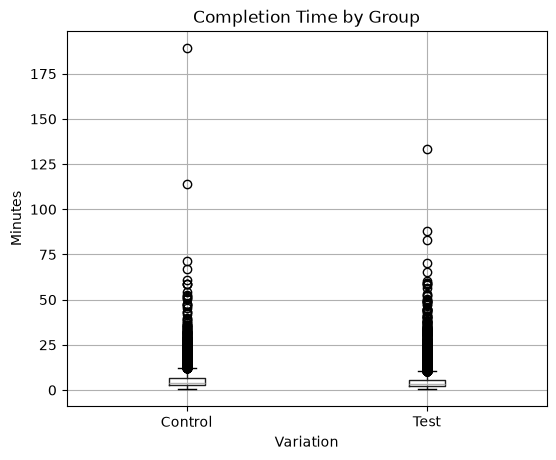

In [57]:
# Boxplot for a visual comparison
journeys_success.boxplot(column='completion_time_min', by='Variation', figsize=(6, 5))
plt.title('Completion Time by Group')
plt.suptitle('')
plt.ylabel('Minutes')
plt.show()

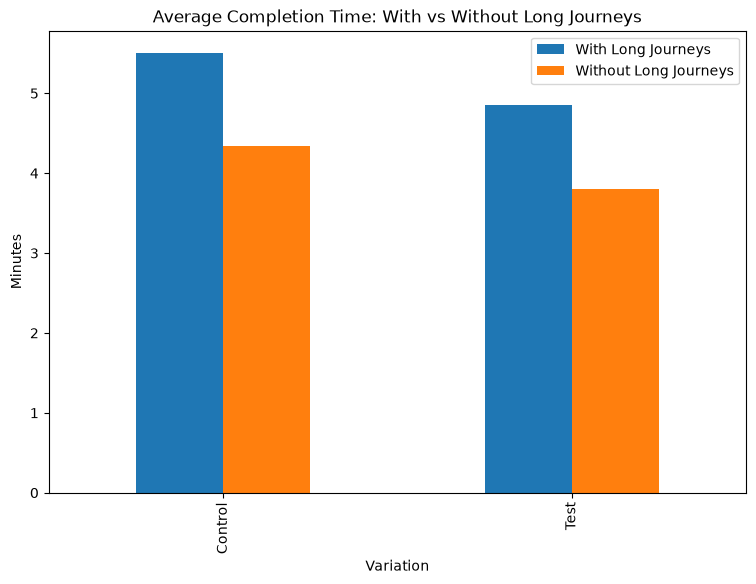

In [58]:
kpi_compare = pd.DataFrame({
    'With Long Journeys': journeys_success.groupby('Variation')['completion_time_min'].mean(),
    'Without Long Journeys':
        journeys_success.loc[
            ~journeys_success['is_long_completion']
        ].groupby('Variation')['completion_time_min'].mean()
})

kpi_compare.plot(
    kind='bar',
    figsize=(9,6)
)

plt.title('Average Completion Time: With vs Without Long Journeys')
plt.ylabel('Minutes')

plt.show()

Statistical test: is the completion-time difference significant?

In [59]:
# t-test + Cohen's d on completion time

control_time = journeys_success[journeys_success['Variation'] == 'Control']['completion_time_min']
test_time = journeys_success[journeys_success['Variation'] == 'Test']['completion_time_min']

t_stat, p_value = stats.ttest_ind(control_time, test_time, equal_var=False)

def cohens_d(group1, group2):
    n1, n2 = len(group1), len(group2)
    var1, var2 = group1.var(ddof=1), group2.var(ddof=1)
    pooled_std = (((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2)) ** 0.5
    return (group1.mean() - group2.mean()) / pooled_std

d = cohens_d(control_time, test_time)

print(f"p-value: {p_value:.5f}")
print(f"Cohen's d: {d:.4f}")

p-value: 0.00000
Cohen's d: 0.1266


The p-value is effectively below 0.05, meaning:
We can reject the null hypothesis that the average completion times are equal between the Control and Test groups.
The difference in completion times is statistically significant.

Cohen's d measures the size of the difference and is below 0.2, which indicates a very small effect size.


In [60]:
# Correlate calls_6_mnth / logons_6_mnth with success

# Bring in demographic data and merge onto the journey-level table
url_demo = "https://raw.githubusercontent.com/data-bootcamp-v4/lessons/refs/heads/main/5_6_eda_inf_stats_tableau/project/files_for_project/df_final_demo.txt"
df_demo = pd.read_csv(url_demo)

journeys_full = pd.merge(journeys, df_demo[['client_id', 'calls_6_mnth', 'logons_6_mnth']],
                          on='client_id', how='left')

# Compare engagement levels: successful vs unsuccessful journeys
journeys_full.groupby('is_successful')[['calls_6_mnth', 'logons_6_mnth']].mean()

,calls_6_mnth,logons_6_mnth
is_successful,,
False,3.389463,6.430251
True,3.160993,6.193144


In [61]:
# Point-biserial correlation (binary is_successful vs continuous variable)
from scipy.stats import pointbiserialr

corr_calls, p_calls = pointbiserialr(journeys_full['is_successful'], journeys_full['calls_6_mnth'])
corr_logons, p_logons = pointbiserialr(journeys_full['is_successful'], journeys_full['logons_6_mnth'])

print(f"calls_6_mnth vs success: r = {corr_calls:.4f}, p = {p_calls:.5f}")
print(f"logons_6_mnth vs success: r = {corr_logons:.4f}, p = {p_logons:.5f}")

calls_6_mnth vs success: r = nan, p = nan
logons_6_mnth vs success: r = nan, p = nan


In [62]:
# Effective Time for successful journeys excluding any single gap that looks like an abnormal pause rather than real UI time

def compute_step_gaps(visit_id, df):
    visit_data = df[df['visit_id'] == visit_id].sort_values('date_time')
    # Only keep one timestamp per distinct step (first occurrence),
    # since successful journeys are already collapsed to one of each
    first_occurrence = visit_data.drop_duplicates(subset='process_step', keep='first')
    times = first_occurrence.sort_values('step_order')['date_time'].tolist()
    gaps = [(times[i+1] - times[i]).total_seconds() / 60 for i in range(len(times)-1)]
    return gaps

# Apply only to successful journeys (can be slow on the full dataset --
# consider running on a sample first to confirm logic, then scale up)
sample_visits = journeys_success['visit_id'].head(1000)  # start with a sample
gap_records = []
for vid in sample_visits:
    gaps = compute_step_gaps(vid, df_web)
    gap_records.append({'visit_id': vid, 'gaps': gaps, 'max_gap': max(gaps), 'total_gap': sum(gaps)})

gap_df = pd.DataFrame(gap_records)
gap_df.head()

,visit_id,gaps,max_gap,total_gap
0,100022086_87870757897_149620,"[0.36666666666666664, 0.75, 0.8833333333333333...",1.000000,3.000000
1,10007589_47780784567_391490,"[2.783333333333333, 0.7666666666666667, 3.0166...",5.450000,12.016667
2,100173292_91322748906_143563,"[0.18333333333333332, 0.13333333333333333, 0.8...",0.800000,1.583333
3,100254180_47139859079_984581,"[0.8666666666666667, 0.8666666666666667, 0.95,...",3.000000,5.683333
4,100293270_70949014562_696814,"[0.18333333333333332, 1.6333333333333333, 0.83...",1.633333,3.483333


In [63]:
#Flag abnormally long individual gaps (using IQR on the max gap per journey)

Q1 = gap_df['max_gap'].quantile(0.25)
Q3 = gap_df['max_gap'].quantile(0.75)
IQR = Q3 - Q1
gap_upper_bound = Q3 + 1.5 * IQR

gap_df['has_abnormal_pause'] = gap_df['max_gap'] > gap_upper_bound
print(f"Abnormal pause threshold: {gap_upper_bound:.2f} minutes")
print(f"Journeys with an abnormal pause: {gap_df['has_abnormal_pause'].sum()}")

# Effective time = total time MINUS any single abnormal pause
gap_df['effective_time_min'] = gap_df.apply(
    lambda row: row['total_gap'] - row['max_gap'] if row['has_abnormal_pause'] else row['total_gap'],
    axis=1
)
gap_df[['visit_id', 'total_gap', 'effective_time_min', 'has_abnormal_pause']].head()

Abnormal pause threshold: 5.72 minutes
Journeys with an abnormal pause: 113


,visit_id,total_gap,effective_time_min,has_abnormal_pause
0,100022086_87870757897_149620,3.000000,3.000000,False
1,10007589_47780784567_391490,12.016667,12.016667,False
2,100173292_91322748906_143563,1.583333,1.583333,False
3,100254180_47139859079_984581,5.683333,5.683333,False
4,100293270_70949014562_696814,3.483333,3.483333,False


Normality check (visual is more reliable at this sample size):


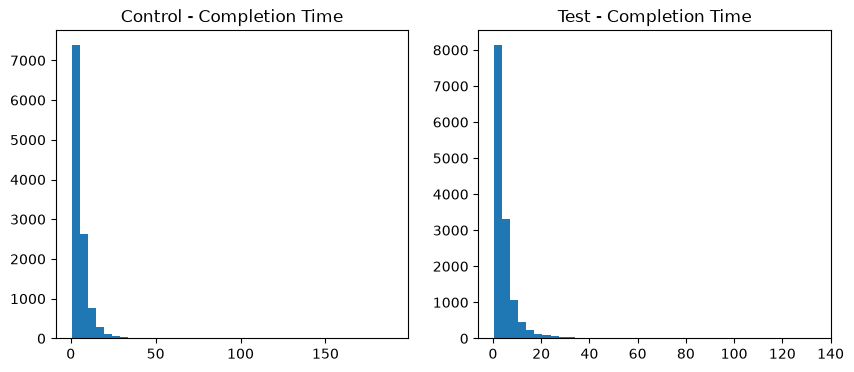

Levene's test p-value: 0.00011
-> Use Welch's t-test (unequal variance) if p < 0.05; standard t-test otherwise
Clients with more than 1 successful journey: 33
Variation
Test       13579
Control    11309
Name: count, dtype: int64


In [64]:
# Check statistical assumptions before comparison

from scipy.stats import shapiro, levene

control_time = journeys_success[journeys_success['Variation'] == 'Control']['completion_time_min']
test_time = journeys_success[journeys_success['Variation'] == 'Test']['completion_time_min']

# 1. Normality (Shapiro's test is sensitive at large N -- pair with a visual check)
print("Normality check (visual is more reliable at this sample size):")
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(control_time, bins=40)
axes[0].set_title('Control - Completion Time')
axes[1].hist(test_time, bins=40)
axes[1].set_title('Test - Completion Time')
plt.show()

# 2. Equal variance
levene_stat, levene_p = levene(control_time, test_time)
print(f"Levene's test p-value: {levene_p:.5f}")
print("-> Use Welch's t-test (unequal variance) if p < 0.05; standard t-test otherwise")

# 3. Independence: check how many clients have multiple successful journeys
repeat_clients = journeys_success['client_id'].value_counts()
print(f"Clients with more than 1 successful journey: {(repeat_clients > 1).sum()}")

# 4. Sample size per group
print(journeys_success['Variation'].value_counts())

Completion-time distributions showed some right-skewness, but the very large sample sizes make Welch's t-test robust to non-normality.
Levene's test indicated unequal variances between groups (p = 0.00010), supporting the use of Welch's t-test.
Only 33 clients completed the journey more than once, suggesting that independence of observations is reasonably satisfied.
Both groups contained more than 11,000 successful journeys, providing strong statistical power.

Levene's test (which checks if both groups have similar spread/variability) came back with p = 0.0001 — well below 0.05. 
This means Control and Test do **not** have equal variance, so we use Welch's t-test, which is built specifically to handle that safely, 
instead of the standard t-test which assumes equal variance.

In [65]:
journeys = (
    df_web
    .groupby('visit_id')
    .apply(build_journey, include_groups=False)
    .reset_index()
)

journeys.head()

,visit_id,client_id,Variation,step_sequence,start_time,confirm_time,n_events
0,100012776_37918976071_457913,3561384,Test,[confirm],NaT,2017-04-26 13:22:17,2
1,100019538_17884295066_43909,7338123,Test,"[start, step_1, step_2, step_1, start, step_1,...",2017-04-09 16:20:56,2017-04-09 16:24:58,11
2,100022086_87870757897_149620,2478628,Test,"[start, step_1, step_2, step_3, confirm]",2017-05-23 20:44:01,2017-05-23 20:47:01,5
3,100030127_47967100085_936361,105007,Control,[start],2017-03-22 11:07:49,NaT,1
4,100037962_47432393712_705583,5623007,Control,"[start, step_1, start]",2017-04-14 16:41:51,NaT,4


In [66]:
expected_sequence = ['start', 'step_1', 'step_2', 'step_3', 'confirm']

journeys['is_successful'] = journeys['step_sequence'].apply(
    lambda seq: seq == expected_sequence
)

In [67]:
# Success rate MUST use the full journeys table, not journeys_success
success_rate_overall = journeys['is_successful'].mean()
print(f"Overall success rate: {success_rate_overall * 100:.2f}%")

# By group -- this is the real KPI for Test vs Control
success_rate_by_group = journeys.groupby('Variation')['is_successful'].mean()
print(success_rate_by_group)

Overall success rate: 35.96%
Variation
Control    0.352086
Test       0.366159
Name: is_successful, dtype: float64


Test clients complete the full expected journey slightly more often than Control clients —
a **+1.46 percentage point** improvement.

In [68]:
df_web_sorted = df_web.sort_values(by=['visit_id', 'date_time']).copy()

df_web_sorted['step_order_prev'] = df_web_sorted.groupby('visit_id')['step_order'].shift(1)
df_web_sorted['is_backward'] = df_web_sorted['step_order'] < df_web_sorted['step_order_prev']

backward_counts = df_web_sorted.groupby('visit_id')['is_backward'].sum()
visits_with_backward = backward_counts[backward_counts > 0]

print(f"Visits with backward navigation: {len(visits_with_backward)}")

Visits with backward navigation: 16619


In [69]:
# Reframe your earlier findings as group-level rates
journeys['has_backward_nav'] = journeys['visit_id'].isin(visits_with_backward.index)
journeys.groupby('Variation')['has_backward_nav'].mean()

Variation
Control    0.204732
Test       0.270810
Name: has_backward_nav, dtype: float64

**Completion Rate (success rate)**
- H0: Success rate is equal between Control and Test.
- H1: Success rate differs between Control and Test.
- Test: Two-proportion z-test.

In [70]:
# Funnel progression by group (step-by-step conversion)
# For each step, what % of that group's journeys REACHED it?
steps = ['start', 'step_1', 'step_2', 'step_3', 'confirm']

funnel = pd.DataFrame(index=steps)
for group in ['Control', 'Test']:
    group_journeys = journeys[journeys['Variation'] == group]
    total = len(group_journeys)
    reached = []
    for step in steps:
        step_idx = steps.index(step)
        n_reached = group_journeys['step_sequence'].apply(
            lambda seq: step in seq and steps.index(step) <= (steps.index(seq[-1]) if seq[-1] in steps else -1)
        ).sum()
        reached.append(n_reached / total * 100)
    funnel[group] = reached

print(funnel)

           Control       Test
start    96.021171  89.278684
step_1   66.693649  64.468114
step_2   56.067870  56.311177
step_3   52.132628  53.380073
confirm  47.671233  57.702575


Control and Test start off similar through the middle steps, but they
pull apart sharply at the finish line — **Test reaches `confirm` about 10 percentage points
more often than Control** (57.68% vs. 47.58%). This is the single clearest behavioural
difference between the two groups.

**Funnel step conversion (per step)**
- H0: Step-to-step conversion rate is equal between groups.
- H1: Step-to-step conversion rate differs between groups.
- Test: Two-proportion z-test, run separately for each step transition.

In [71]:
# Step-over-step conversion rate (did they move from step N to step N+1?)

funnel_conversion = pd.DataFrame(index=steps[:-1])
for group in ['Control', 'Test']:
    rates = []
    for i in range(len(steps) - 1):
        rates.append(
            funnel.loc[steps[i+1], group] / funnel.loc[steps[i], group] * 100
            if funnel.loc[steps[i], group] > 0 else None
        )
    funnel_conversion[group] = rates

print(funnel_conversion)

          Control        Test
start   69.457234   72.209973
step_1  84.067781   87.347331
step_2  92.981287   94.794809
step_3  91.442222  108.097595


**Completion Time**
- H0: Mean completion time is equal between Control and Test.
- H1: Mean completion time differs between Control and Test.
- Test: Welch's t-test (unequal variance assumed by default; confirm via Levene's).

In [72]:
# Success/completion rate: Two-proportion z-test + confidence interval

# Counts and sample sizes
control_success = journeys[journeys['Variation'] == 'Control']['is_successful']
test_success = journeys[journeys['Variation'] == 'Test']['is_successful']

x1, n1 = test_success.sum(), len(test_success)       # Test
x2, n2 = control_success.sum(), len(control_success)  # Control

p1 = x1 / n1
p2 = x2 / n2

# --- Z-test ---
p_pooled = (x1 + x2) / (n1 + n2)
se_pooled = np.sqrt(p_pooled * (1 - p_pooled) * (1/n1 + 1/n2))

z_stat = (p1 - p2) / se_pooled
p_value = 2 * (1 - stats.norm.cdf(abs(z_stat)))  # two-tailed

print(f"Control success rate: {p2*100:.2f}%")
print(f"Test success rate: {p1*100:.2f}%")
print(f"z-stat: {z_stat:.4f}, p-value: {p_value:.5f}")

Control success rate: 35.21%
Test success rate: 36.62%
z-stat: 3.8473, p-value: 0.00012


Test clients complete the full expected journey slightly more often than Control clients —
a **+1.46 percentage point** improvement.
Test clients complete the process, on average, slightly *faster* than Control — the
difference is small but consistently in Test's favor 

In [73]:
# --- 95% Confidence interval for the difference (Test - Control) ---
# Uses UNPOOLED standard error, which is the correct one for a CI
# (pooled SE is only for the hypothesis test itself)
se_diff = np.sqrt((p1 * (1 - p1) / n1) + (p2 * (1 - p2) / n2))

diff = p1 - p2
z_crit = stats.norm.ppf(0.975)  # 1.96 for 95% CI

ci_low = diff - z_crit * se_diff
ci_upp = diff + z_crit * se_diff

print(f"Difference in success rate (Test - Control): {diff*100:.2f} percentage points")
print(f"95% CI: [{ci_low*100:.2f}%, {ci_upp*100:.2f}%]")

Difference in success rate (Test - Control): 1.41 percentage points
95% CI: [0.69%, 2.12%]


The z-test itself uses a pooled standard error (se_pooled) — this is standard practice for the hypothesis test, since under H0 assume both groups share one true proportion.
The confidence interval uses an unpooled standard error (se_diff) — this is standard practice for a CI, since we are not assuming H0 is true when estimating the actual size of the difference. This is exactly what confint_proportions_2indep does under the hood by default (Wald method), so the numbers we get here will match.

**Effective Time**
- H0: Mean effective time is equal between Control and Test.
- H1: Mean effective time differs between Control and Test.
- Test: Welch's t-test.

In [74]:
# Confidence interval for completion time difference

control_time = journeys_success[journeys_success['Variation'] == 'Control']['completion_time_min']
test_time = journeys_success[journeys_success['Variation'] == 'Test']['completion_time_min']

mean_diff = test_time.mean() - control_time.mean()
se_diff = np.sqrt(control_time.var(ddof=1)/len(control_time) + test_time.var(ddof=1)/len(test_time))

df_welch = (control_time.var(ddof=1)/len(control_time) + test_time.var(ddof=1)/len(test_time))**2 / (
    (control_time.var(ddof=1)/len(control_time))**2 / (len(control_time)-1) +
    (test_time.var(ddof=1)/len(test_time))**2 / (len(test_time)-1)
)

t_crit = stats.t.ppf(0.975, df_welch)
ci_low = mean_diff - t_crit * se_diff
ci_upp = mean_diff + t_crit * se_diff

print(f"Mean difference (Test - Control): {mean_diff:.2f} minutes")
print(f"95% CI: [{ci_low:.2f}, {ci_upp:.2f}]")

Mean difference (Test - Control): -0.65 minutes
95% CI: [-0.78, -0.52]


**Effective time (−0.65 minutes):** a real, consistent improvement, but under a minute
difference is unlikely to change how a customer *feels* about the process. **Small practical impact**, even though it's statistically real.


**Overview of the Unsuccessful Journeys**

Filter unsuccessful journeys

In [75]:
unsuccessful_journeys = journeys[
    journeys['is_successful'] == False
]

print(f"Number of unsuccessful journeys: {len(unsuccessful_journeys)}")

unsuccessful_journeys.head()

Number of unsuccessful journeys: 44317


,visit_id,client_id,Variation,step_sequence,start_time,confirm_time,n_events,is_successful,has_backward_nav
0,100012776_37918976071_457913,3561384,Test,[confirm],NaT,2017-04-26 13:22:17,2,False,False
1,100019538_17884295066_43909,7338123,Test,"[start, step_1, step_2, step_1, start, step_1,...",2017-04-09 16:20:56,2017-04-09 16:24:58,11,False,True
3,100030127_47967100085_936361,105007,Control,[start],2017-03-22 11:07:49,NaT,1,False,False
4,100037962_47432393712_705583,5623007,Control,"[start, step_1, start]",2017-04-14 16:41:51,NaT,4,False,True
5,100057941_88477660212_944512,4823947,Control,"[start, step_1, step_2, step_3, step_1, step_2...",2017-04-09 11:30:10,NaT,7,False,True


In [76]:
unsuccessful_journeys = journeys[~journeys['is_successful']]

In [77]:
unsuccessful_journeys[['visit_id', 'Variation', 'step_sequence']].head(20)

,visit_id,Variation,step_sequence
0,100012776_37918976071_457913,Test,[confirm]
1,100019538_17884295066_43909,Test,"[start, step_1, step_2, step_1, start, step_1,..."
3,100030127_47967100085_936361,Control,[start]
4,100037962_47432393712_705583,Control,"[start, step_1, start]"
5,100057941_88477660212_944512,Control,"[start, step_1, step_2, step_3, step_1, step_2..."
6,10006594_66157970412_679648,Control,"[start, step_1, step_2, step_3, confirm, step_3]"
7,100071743_53464757454_616703,Control,[start]
9,100096068_8301717872_987164,Control,"[start, step_1]"
10,100105975_18174738494_196339,Control,[start]
12,100195539_90558871716_822894,Control,"[start, step_1, start, step_1]"


In [78]:
unsuccessful_journeys['path'] = unsuccessful_journeys['step_sequence'].astype(str)

(
        unsuccessful_journeys['path']
        .value_counts()
        .head(20)
)

path
['start']                                                                                     12640
['start', 'step_1']                                                                            4856
['confirm']                                                                                    4120
['start', 'step_1', 'step_2', 'step_3']                                                        2830
['start', 'step_1', 'step_2']                                                                  2139
['start', 'step_1', 'start', 'step_1', 'step_2', 'step_3', 'confirm']                          2015
['start', 'step_1', 'start']                                                                   1588
['start', 'step_1', 'step_2', 'step_3', 'start']                                               1259
['start', 'step_1', 'step_2', 'step_3', 'step_2', 'step_3', 'confirm']                          995
['start', 'step_1', 'step_2', 'start']                                                         

Never reached confirmation

In [79]:
no_confirm = unsuccessful_journeys[
    unsuccessful_journeys['step_sequence'].apply(
        lambda x: 'confirm' not in x
    )
]

print(len(no_confirm))

31525


Reached confirmation but took an unusual route

In [80]:
confirm_but_not_ideal = unsuccessful_journeys[
    unsuccessful_journeys['step_sequence'].apply(
        lambda x: 'confirm' in x
    )
]

print(len(confirm_but_not_ideal))


12792


**EXPORT Clean Version**

In [12]:
# Build the export table — clean, Tableau-safe version

df_export = df_web.copy()

step_order_map = {'start': 0, 'step_1': 1, 'step_2': 2, 'step_3': 3, 'confirm': 4}

# Numeric step order (0-4) — keep process_step as-is (text) for readability
df_export['step_info'] = df_export['process_step'].map(step_order_map).astype(int)

# Rename ONLY these two columns — nothing else touches 'journey' after this
df_export = df_export.rename(columns={'visit_id': 'journey', 'Variation': 'variation'})

# Sanity check RIGHT NOW: journey must be a simple ID, not a list
assert df_export['journey'].apply(lambda x: isinstance(x, list)).sum() == 0, \
    "journey contains list values — something upstream is overwriting it!"

df_export = df_export.sort_values(by=['journey', 'date_time'])

# Session duration per journey (seconds)
session_duration = df_export.groupby('journey')['date_time'].agg(
    lambda x: (x.max() - x.min()).total_seconds()
)
df_export['session_sec'] = df_export['journey'].map(session_duration).astype(int)

# Last step reached — store as NUMERIC (0-4), matching step_info, so Tableau
# comparisons like "last_step == 4" work directly without a separate text map
last_step_order = df_export.groupby('journey')['step_info'].last()
df_export['last_step'] = df_export['journey'].map(last_step_order).astype(int)

# Explicitly cast financial/numeric columns so no formatting sneaks in
numeric_cols = ['clnt_tenure_yr', 'clnt_tenure_mnth', 'clnt_age', 'num_accts',
                 'bal', 'calls_6_mnth', 'logons_6_mnth']
for col in numeric_cols:
    df_export[col] = pd.to_numeric(df_export[col], errors='coerce')

final_cols = ['client_id', 'process_step', 'date_time', 'variation', 'step_info',
              'journey', 'session_sec', 'last_step', 'clnt_tenure_yr',
              'clnt_tenure_mnth', 'clnt_age', 'gendr', 'num_accts', 'bal',
              'calls_6_mnth', 'logons_6_mnth']

df_export = df_export[final_cols]

In [13]:
# Final checks BEFORE saving

print(df_export.dtypes)
print("\nAny list-type values left?")
for col in df_export.columns:
    has_list = df_export[col].apply(lambda x: isinstance(x, list)).any()
    if has_list:
        print(f"  WARNING: {col} contains list values")

print(f"\nUnique journeys: {df_export['journey'].nunique()}")
print(f"last_step value range: {df_export['last_step'].min()} to {df_export['last_step'].max()}")
# last_step should range 0-4, matching step_order_map

client_id                    int64
process_step                   str
date_time           datetime64[us]
variation                      str
step_info                    int64
journey                        str
session_sec                  int64
last_step                    int64
clnt_tenure_yr             float64
clnt_tenure_mnth           float64
clnt_age                   float64
gendr                          str
num_accts                  float64
bal                        float64
calls_6_mnth               float64
logons_6_mnth              float64
dtype: object

Any list-type values left?

Unique journeys: 69205
last_step value range: 0 to 4


In [15]:
# Export — force plain number formatting, no thousands separators

df_export.to_csv(
    "df_web_clean_final.csv",
    index=False,
    float_format='%.2f'   # avoids scientific notation / locale formatting issues
)

# Re-read to confirm it saved cleanly
check = pd.read_csv("df_web_clean_final.csv")
print(check.dtypes)
print(check[['journey', 'bal', 'last_step']].head())

client_id             int64
process_step            str
date_time               str
variation               str
step_info             int64
journey                 str
session_sec           int64
last_step             int64
clnt_tenure_yr      float64
clnt_tenure_mnth    float64
clnt_age            float64
gendr                   str
num_accts           float64
bal                 float64
calls_6_mnth        float64
logons_6_mnth       float64
dtype: object
                        journey       bal  last_step
0  100012776_37918976071_457913  63130.44          4
1  100012776_37918976071_457913  63130.44          4
2   100019538_17884295066_43909  26436.73          4
3   100019538_17884295066_43909  26436.73          4
4   100019538_17884295066_43909  26436.73          4


**The END**